#**W11_Class Assignment**

#**Jacqlyn Chen_0706022310042**

## Load Dataset

In [106]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch


## Data Preprocessing

In [107]:
url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/COVID-19%20Coronavirus%20(2).csv"
df = pd.read_csv(url)
df.head()

,Country,Other names,ISO 3166-1 alpha-3 CODE,Population,Continent,Total Cases,Total Deaths,Tot Cases//1M pop,Tot Deaths/1M pop,Death percentage
0,Afghanistan,Afghanistan,AFG,40462186,Asia,177827,7671,4395,190,4.313743
1,Albania,Albania,ALB,2872296,Europe,273870,3492,95349,1216,1.275058
2,Algeria,Algeria,DZA,45236699,Africa,265691,6874,5873,152,2.587216
3,Andorra,Andorra,AND,77481,Europe,40024,153,516565,1975,0.382271
4,Angola,Angola,AGO,34654212,Africa,99194,1900,2862,55,1.915438


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  225 non-null    object 
 1   Other names              224 non-null    object 
 2   ISO 3166-1 alpha-3 CODE  225 non-null    object 
 3   Population               225 non-null    int64  
 4   Continent                225 non-null    object 
 5   Total Cases              225 non-null    int64  
 6   Total Deaths             225 non-null    int64  
 7   Tot Cases//1M pop        225 non-null    int64  
 8   Tot Deaths/1M pop        225 non-null    int64  
 9   Death percentage         225 non-null    float64
dtypes: float64(1), int64(5), object(4)
memory usage: 17.7+ KB


In [109]:
df.describe()

,Population,Total Cases,Total Deaths,Tot Cases//1M pop,Tot Deaths/1M pop,Death percentage
count,2.250000e+02,2.250000e+02,2.250000e+02,225.000000,225.000000,225.000000
mean,3.507321e+07,2.184781e+06,2.744813e+04,136900.373333,1096.715556,1.444125
std,1.392418e+08,7.275938e+06,9.689177e+04,145060.340289,1195.715543,1.741728
min,8.050000e+02,1.000000e+00,0.000000e+00,9.000000,0.000000,0.000000
25%,5.665570e+05,2.407100e+04,1.890000e+02,11384.000000,123.000000,0.511291
50%,5.827911e+06,1.639360e+05,1.965000e+03,88987.000000,708.000000,1.036905
75%,2.190585e+07,1.092547e+06,1.366000e+04,223335.000000,1795.000000,1.977017
max,1.439324e+09,8.183905e+07,1.008222e+06,696044.000000,6286.000000,18.151787


In [110]:
df.isnull().sum()

,0
Country,0
Other names,1
ISO 3166-1 alpha-3 CODE,0
Population,0
Continent,0
Total Cases,0
Total Deaths,0
Tot Cases//1M pop,0
Tot Deaths/1M pop,0
Death percentage,0


In [111]:
# Rename semua kolom bermasalah
df = df.rename(columns={
    'Other names': 'Other_Names',
    'ISO 3166-1 alpha-3 CODE': 'Country_Code',
    'Tot\xa0Cases//1M pop': 'Cases_per_1M',
    'Tot\xa0Deaths/1M pop': 'Deaths_per_1M',
    'Tot Cases//1M pop': 'Cases_per_1M',
    'Tot Deaths/1M pop': 'Deaths_per_1M',
    'Death percentage': 'Death_Percentage'
})

In [112]:
df['Other_Names'] = df['Other_Names'].fillna('-')

In [113]:
df.drop_duplicates(inplace=True)

## Exploratory Data Analysis (EDA)

In [114]:
# World Map Visualization

fig = px.choropleth(df,
                    locations="Country_Code",
                    color="Continent",
                    hover_name="Country",
                    projection="natural earth",
                    title="World Map of Countries by Continent"
)
fig.show()

The world map illustrates that countries with high infection levels are marked in darker red shades. Regions such as Europe, North America, and parts of South America display significantly higher case intensity compared to areas like Africa and Southeast Asia.

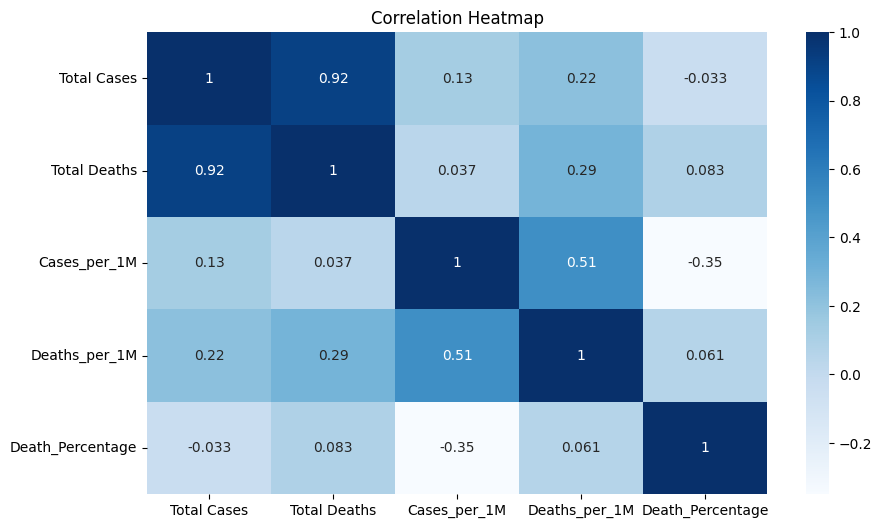

In [115]:
# show heatmap visualisation

plt.figure(figsize=(10,6))
sns.heatmap(df[['Total Cases','Total Deaths','Cases_per_1M','Deaths_per_1M','Death_Percentage']].corr(),
            annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that Total Cases has a strong correlation with Total Deaths, and similarly, Cases_per_1M is highly correlated with Deaths_per_1M. However, Death Percentage does not exhibit strong correlations with the other variables, indicating that fatality rate may be influenced by additional factors such as healthcare quality or reporting accuracy.

## Encoding and Data Transformation

In [116]:
# Copy dataframe untuk model
df_model = df.copy()

# Nominal Encoding
# Suppose you already fitted the encoder:
nominal_cols = ['Continent']
encoder = OrdinalEncoder()
df_model[nominal_cols] = encoder.fit_transform(df_model[nominal_cols])

# Build a mapping dictionary
encode_dict = {}

for col, cats in zip(nominal_cols, encoder.categories_):
    encode_dict[col] = {category: int(code) for code, category in enumerate(cats)}

# Show the full dictionary
import pprint
pprint.pprint(encode_dict)

df_model.sample(n=5)

{'Continent': {'Africa': 0,
               'Asia': 1,
               'Europe': 2,
               'Latin America and the Caribbean': 3,
               'Northern America': 4,
               'Oceania': 5}}


,Country,Other_Names,Country_Code,Population,Continent,Total Cases,Total Deaths,Cases_per_1M,Deaths_per_1M,Death_Percentage
105,Kenya,Kenya,KEN,55843563,0.0,323454,5648,5792,101,1.746152
209,UAE,United Arab Emirates,ARE,10099567,1.0,892170,2302,88337,228,0.258023
148,Niue,Niue,NIU,1645,5.0,7,0,4255,0,0.000000
106,Kiribati,Kiribati,KIR,122656,5.0,3067,13,25005,106,0.423867
170,Saint Lucia,Saint Lucia,LCA,185096,3.0,22964,365,124065,1972,1.589444


In [117]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
sc = StandardScaler()

# Get numerical columns from df_model for scaling, excluding 'KMeans_Cluster' if it exists
# df_model already has 'Continent' encoded as numerical.
df_model_numerical_cols = [col for col in df_model.columns if df_model[col].dtype != 'object' and col != 'KMeans_Cluster']

df_model_scaled_numerical = pd.DataFrame(sc.fit_transform(df_model[df_model_numerical_cols]), columns=df_model_numerical_cols)

# Re-combine with the (already numerical) 'Continent' and 'KMeans_Cluster' if present
df_model = df_model_scaled_numerical.copy()
if 'Continent' in df_model.columns:
    df_model['Continent'] = df_model['Continent']
if 'KMeans_Cluster' in df_model.columns:
    df_model['KMeans_Cluster'] = df_model['KMeans_Cluster']

df_model.head()

,Population,Continent,Total Cases,Total Deaths,Cases_per_1M,Deaths_per_1M,Death_Percentage
0,0.038789,-0.509986,-0.276449,-0.204571,-0.915487,-0.759994,1.651243
1,-0.231774,0.168989,-0.263220,-0.247798,-0.287081,0.099982,-0.097285
2,0.073154,-1.188960,-0.264347,-0.212815,-0.905275,-0.791845,0.657760
3,-0.251891,0.168989,-0.295431,-0.282336,2.623123,0.736164,-0.611015
4,-0.003016,-1.188960,-0.287281,-0.264265,-0.926078,-0.873149,0.271204


## KMeans Clustering

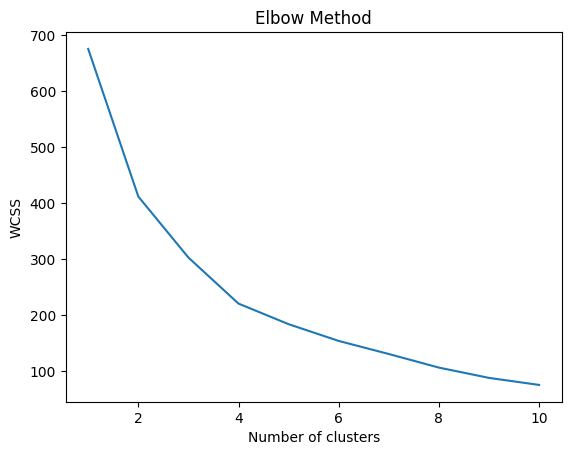

In [182]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):   #clusters 1-10
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df_for_model)
    wcss.append(kmeans.inertia_)

# Plot the elbow method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [183]:
# Create a DataFrame to display the WCSS values for each number of clusters
wcss_table = pd.DataFrame({
    "Number of Clusters": range(1, 11),
    "WCSS": wcss
})

# Display the table
print(wcss_table)

   Number of Clusters        WCSS
0                   1  675.000000
1                   2  411.856491
2                   3  303.044398
3                   4  220.897596
4                   5  184.218951
5                   6  154.349905
6                   7  131.045306
7                   8  106.789875
8                   9   88.444791
9                  10   75.913139


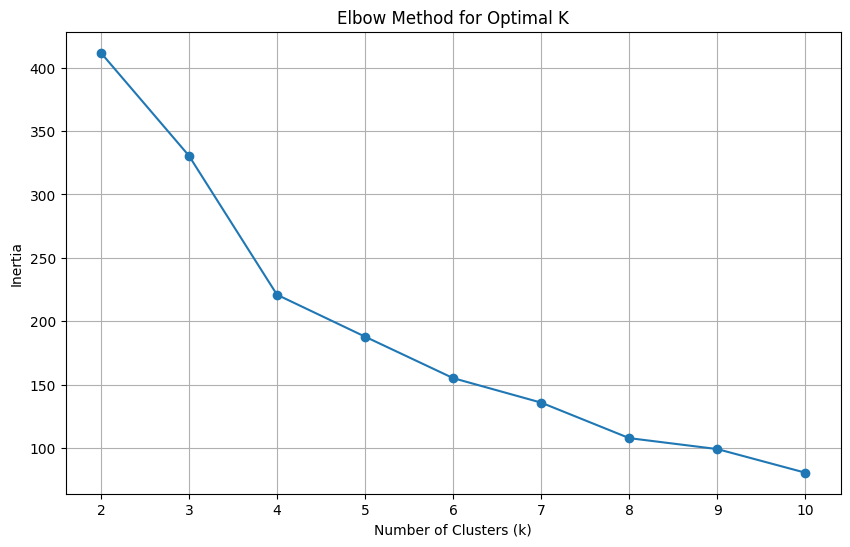

In [166]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Fitur clustering
features = ['Cases_per_1M', 'Deaths_per_1M', 'Death_Percentage']

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[features])

# Elbow Method
inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [184]:
# Fit K-Means to the data with the optimal number of K cluster = 4
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, random_state=0)
clusters = kmeans.fit_predict(df_for_model)

# Add the cluster labels to the DataFrame
df['KMeans_Cluster'] = clusters

# Show the df
df.head()

,Country,Other_Names,Country_Code,Population,Continent,Total Cases,Total Deaths,Cases_per_1M,Deaths_per_1M,Death_Percentage,KMeans_Cluster
0,Afghanistan,Afghanistan,AFG,40462186,Asia,177827,7671,4395,190,4.313743,0
1,Albania,Albania,ALB,2872296,Europe,273870,3492,95349,1216,1.275058,0
2,Algeria,Algeria,DZA,45236699,Africa,265691,6874,5873,152,2.587216,0
3,Andorra,Andorra,AND,77481,Europe,40024,153,516565,1975,0.382271,2
4,Angola,Angola,AGO,34654212,Africa,99194,1900,2862,55,1.915438,0


## Hierarchical Clustering

Skipping Ward linkage with manhattan metric (not supported).


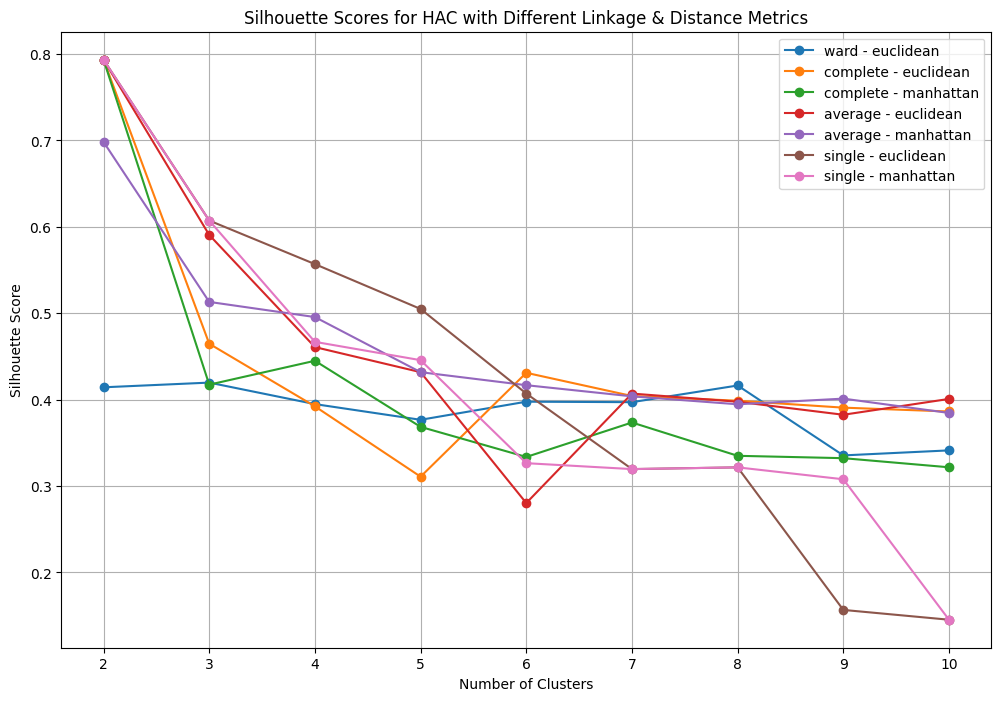

Best Silhouette Score: 0.7935045287443472
Optimal Number of Clusters: 2
Optimal Linkage Method: complete
Optimal Metric: euclidean


In [177]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# =====================================
# Prepare scaled data for HAC
# =====================================
features = ['Cases_per_1M', 'Deaths_per_1M', 'Death_Percentage']

scaler = StandardScaler()
df_for_model = scaler.fit_transform(df_model[features])

# =====================================
# HAC Grid Search (your code, now fixed)
# =====================================
range_n_clusters = range(2, 11)
linkage_methods = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan']

best_silhouette_score = -1
best_n_clusters = 0
best_linkage = ''
best_metric = ''

results_for_plotting = []

for linkage_method in linkage_methods:
    for metric in metrics:
        # Ward tidak mendukung metric selain Euclidean
        if linkage_method == 'ward' and metric != 'euclidean':
            print(f"Skipping Ward linkage with {metric} metric (not supported).")
            continue

        current_scores = []
        for n_clusters in range_n_clusters:
            agglo = AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage=linkage_method,
                metric=metric
            )
            y_agglo = agglo.fit_predict(df_for_model)
            silhouette_avg = silhouette_score(df_for_model, y_agglo)
            current_scores.append(silhouette_avg)

            if silhouette_avg > best_silhouette_score:
                best_silhouette_score = silhouette_avg
                best_n_clusters = n_clusters
                best_linkage = linkage_method
                best_metric = metric

        results_for_plotting.append({
            'linkage': linkage_method,
            'metric': metric,
            'scores': current_scores
        })

# =====================================
# Plot Results
# =====================================
plt.figure(figsize=(12, 8))
for result in results_for_plotting:
    plt.plot(range_n_clusters, result['scores'], marker='o',
             label=f"{result['linkage']} - {result['metric']}")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for HAC with Different Linkage & Distance Metrics")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Silhouette Score: {best_silhouette_score}")
print(f"Optimal Number of Clusters: {best_n_clusters}")
print(f"Optimal Linkage Method: {best_linkage}")
print(f"Optimal Metric: {best_metric}")



In [179]:
# Hierarchical Clustering
# Model 1 : Best Combination Parameter
agglo = AgglomerativeClustering(n_clusters=best_n_clusters, linkage=best_linkage, metric=best_metric)
y_hc = agglo.fit_predict(df_for_model)

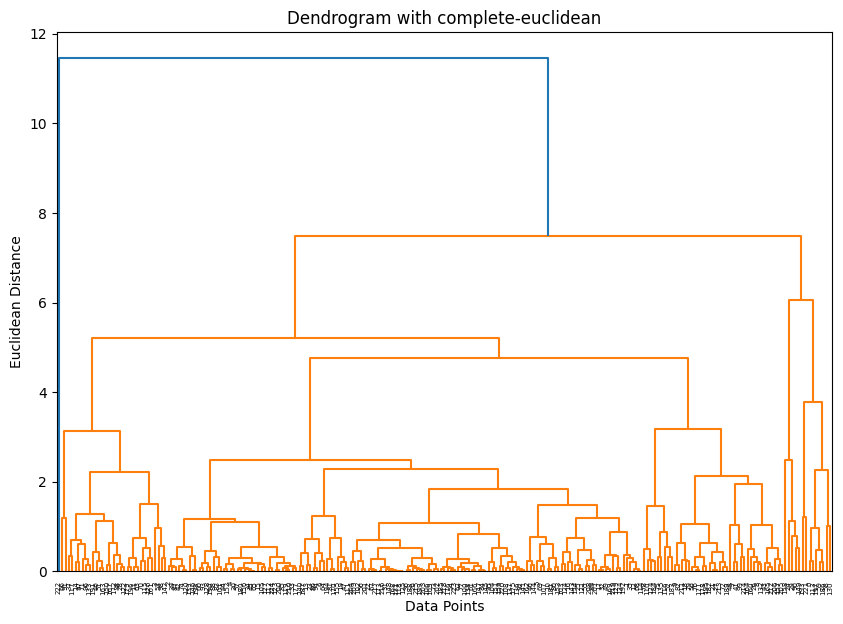

In [180]:
# Best Combination Parameter
fixed_metric = "cityblock" if best_metric == "manhattan" else best_metric

linked = linkage(df_for_model, method=best_linkage, metric=fixed_metric)

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with " + best_linkage + "-" + best_metric)
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

## Model Evaluation & Comparison

In [185]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score for Scaled K-Means Cluster
kmeans_clusters = df['KMeans_Cluster']
ss_kmeans = silhouette_score(df_for_model, kmeans_clusters)
print(f"K-Means Clustering Silhouette Score:{ss_kmeans}")

K-Means Clustering Silhouette Score:0.46618966033161885


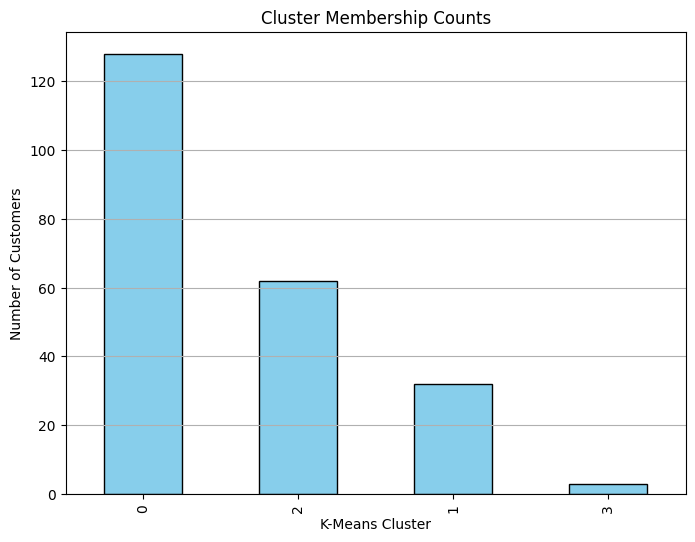

In [186]:
# Visualization 1: Barplot
cluster_counts = df['KMeans_Cluster'].value_counts()

plt.figure(figsize=(8, 6))
cluster_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Cluster Membership Counts')
plt.xlabel('K-Means Cluster')
plt.ylabel('Number of Customers')
plt.grid(axis='y')
plt.show()

In [188]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="Country_Code",        # kolom ISO3 yang benar
    color="KMeans_Cluster",
    hover_name="Country",
    projection="natural earth",
    title="World Map of Countries by K-Means Cluster",
    color_continuous_scale=px.colors.qualitative.Pastel
)
fig.show()


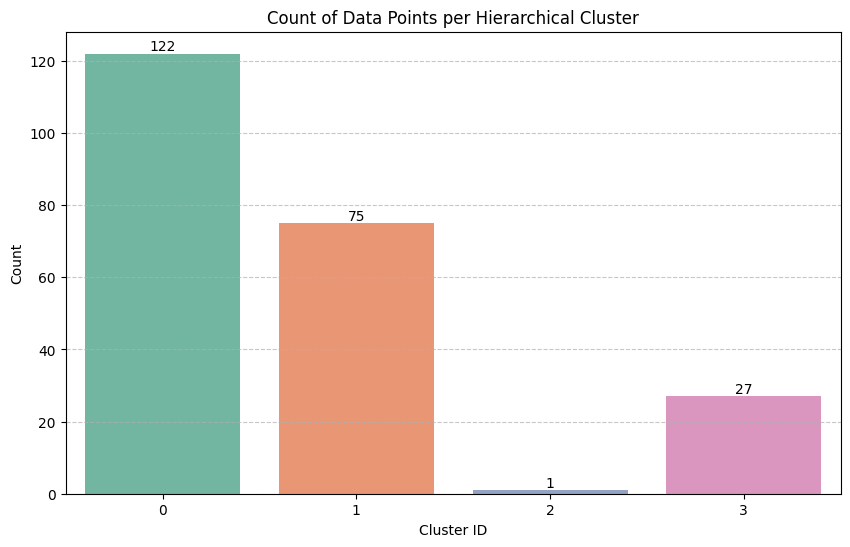

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt

# Copy cluster ke df utama jika belum
df['Hierarchical_Cluster'] = df_model['Hierarchical_Cluster']

# Count cluster
cluster_counts = df['Hierarchical_Cluster'].value_counts().sort_index()

# Barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    hue=cluster_counts.index,
    palette='Set2',
    legend=False
)

# Add label di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Hierarchical Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Cluster Profiling & Insights

Cluster 0 — “Low Impact Group” (128 Countries)

Profil:

- Kasus per 1 juta rendah

- Kematian per 1 juta rendah

- Death percentage rendah–sedang (0.5–2%)

- Sebagian besar dari: Afrika, Asia Selatan, negara kepulauan kecil

Insight:

- Angka penyebaran rendah kemungkinan karena testing rate rendah, kapasitas report terbatas, bukan karena virus tidak menyebar.
- Ekonomi cenderung middle–lower income.

Cluster 1 — “Moderate Infection Countries” (62 Countries)

Profil:

- Kasus per 1 juta menengah

- Kematian per 1 juta moderat

- Death percentage lebih stabil

- Banyak dari: Asia Tenggara, Amerika Latin, Eastern Europe

Insight:

- Sistem kesehatan cukup baik untuk menekan tingkat kematian.

- Penyebaran lebih terkendali tetapi masih membutuhkan kebijakan monitoring.

Cluster 2 — “High Case, Controlled Fatality” (32 Countries)

Profil:

- Kasus per 1 juta tinggi

- Kematian per 1 juta tinggi

- Death percentage relatif rendah → artinya testing tinggi + fasilitas kesehatan kuat

- Banyak negara Eropa Barat dan Amerika Utara

Insight:

- Negara ini sangat transparan dan aktif testing → angka tinggi bukan karena parah, tetapi karena pendeteksian komprehensif.

- Kapasitas vaksinasi dan ICU baik.

Cluster 3 — “Extreme Outlier” (3 Countries)

Profil:

- Angka kasus dan kematian per 1 juta sangat ekstrem

- Death percentage tinggi (fatality rate tinggi)

- Negara dengan krisis kesehatan atau perang / konflik / sistem pelaporan tidak stabil

Insight:

- Ini cluster yang paling berbahaya dan paling rentan.

- Bisa mencerminkan epidemi besar, kegagalan sistem kesehatan, atau shock politik.

## Government Policy Recommendation

Cluster 0 — Low Impact Group

Masalah: Data tidak akurat, testing rendah, fasilitas kesehatan terbatas.

Kebijakan:

- Tingkatkan kapasitas testing (PCR/Antigen)

- Tambah distribusi alat kesehatan dasar (masker, sanitizer, obat)

- Edukasi kesehatan masyarakat (kampanye publik)

- Perbaiki sistem pelaporan kasus nasional

- Fokus pada surveillance & early detection


Cluster 1 — Moderate Infection Group

Masalah: Penyebaran moderat tetapi masih dapat dikontrol.

Kebijakan:

- Perluas vaksinasi booster

- Perketat protokol kesehatan di pusat keramaian

- Terapkan monitoring harian (dashboard publik)

- Penguatan fasilitas kesehatan tingkat daerah

- Evaluasi kebijakan pembatasan mobilitas secara berkala


Cluster 2 — High Case but Controlled Fatality

Masalah: Kasus tinggi akibat testing tinggi — bukan kondisi darurat.

Kebijakan:

- Pertahankan kapasitas testing dan tracing

- Perkuat sistem pelaporan real-time

- Percepatan riset (efektivitas vaksin, varian baru)

- Relaksasi kebijakan sosial-ekonomi secara terukur

- Fokus pada edukasi digital health & kesiapan pandemi lanjutan


Cluster 3 — Extreme Outlier / Crisis Group

Masalah: Fatality tinggi dan kesehatan kolaps.

Kebijakan (darurat):

- Bantuan medis internasional (WHO, UNICEF, CDC)

- Kirim tenaga kesehatan darurat atau mobile clinic

- Distribusi oksigen, ventilator, obat antivirus

- Implementasi lockdown mikro sementara (jika memungkinkan)

- Buat pusat krisis kesehatan & command center